项目背景：一家物流公司在经营过程中出现利润波动，希望提升利润率。

In [1]:
#导入包
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

import warnings
from sqlalchemy.exc import SAWarning

warnings.filterwarnings("ignore", category=SAWarning)

In [2]:
#连接 SQL Server
engine = create_engine(
    "mssql+pyodbc://@.\\SQLEXPRESS/Projects?"
    "driver=ODBC+Driver+17+for+SQL+Server&"
    "trusted_connection=yes&"
    "TrustServerCertificate=yes"
)
#测试一下
pd.read_sql("SELECT TOP 5 name FROM sys.tables", engine)

,name
0,logistics_orders
1,df_orders


In [3]:
#读取数据
df = pd.read_csv("logistics_orders.csv")
df.head()

,order_id,order_date,customer_type,transport_mode,product_type,origin_city,destination_country,month,weight_kg,volume_cbm,...,delay_flag,claim_flag,claim_cost,insurance_cover,company_claim_cost,bad_debt_flag,bad_debt_amount,gross_profit,profit,profit_margin
0,1,2023-01-01 00:00:00,中小客户,海运,家具,青岛,法国,1,863.89,16.91,...,1,1,370.40,277.80,92.60,1,6236.93,575.63,-5821.70,-0.7205
1,2,2023-01-01 01:00:00,中小客户,海运,普货,上海,美国,1,1125.65,19.73,...,1,1,384.49,288.37,96.12,0,0.00,822.68,735.12,0.0986
2,3,2023-01-01 02:00:00,中小客户,海运,电子产品,深圳,英国,1,766.63,18.61,...,1,0,0.00,0.00,0.00,0,0.00,748.51,757.33,0.0940
3,4,2023-01-01 03:00:00,中小客户,铁路,服饰,青岛,日本,1,510.42,11.61,...,1,0,0.00,0.00,0.00,0,0.00,876.06,886.38,0.1255
4,5,2023-01-01 04:00:00,大客户,海运,电子产品,青岛,澳大利亚,1,950.11,9.33,...,1,0,0.00,0.00,0.00,0,0.00,570.90,577.63,0.1070


In [4]:
#检查数据基本情况
df.info()
df.isnull().sum()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 10000 non-null  int64  
 1   order_date               10000 non-null  object 
 2   customer_type            10000 non-null  object 
 3   transport_mode           10000 non-null  object 
 4   product_type             10000 non-null  object 
 5   origin_city              10000 non-null  object 
 6   destination_country      10000 non-null  object 
 7   month                    10000 non-null  int64  
 8   weight_kg                10000 non-null  float64
 9   volume_cbm               10000 non-null  float64
 10  shipping_cost            10000 non-null  float64
 11  customs_cost             10000 non-null  float64
 12  warehouse_cost           10000 non-null  float64
 13  other_cost               10000 non-null  float64
 14  base_total_cost        

,order_id,order_date,customer_type,transport_mode,product_type,origin_city,destination_country,month,weight_kg,volume_cbm,...,delay_flag,claim_flag,claim_cost,insurance_cover,company_claim_cost,bad_debt_flag,bad_debt_amount,gross_profit,profit,profit_margin
count,10000.00000,10000,10000,10000,10000,10000,10000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,10000,2,4,5,5,6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2023-01-01 00:00:00,中小客户,海运,普货,广州,日本,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6445,4936,2971,2096,1691,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,NaN,NaN,NaN,NaN,5.890400,590.794096,12.706549,...,0.562200,0.112400,64.150877,48.113157,16.037717,0.015000,83.308643,786.062256,694.807143,0.101112
std,2886.89568,NaN,NaN,NaN,NaN,NaN,NaN,3.646768,289.741398,5.976878,...,0.496141,0.315874,196.902534,147.676909,49.225628,0.121559,711.094071,296.198432,776.638733,0.106348
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,50.720000,1.010000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,233.290000,-10278.810000,-0.923200
25%,2500.75000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,356.660000,8.277500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,567.047500,550.030000,0.091100
50%,5000.50000,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,553.645000,12.065000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,738.695000,726.515000,0.107600
75%,7500.25000,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,812.762500,17.070000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,954.080000,943.282500,0.126700


In [5]:
#处理日期格式
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.order_date)

0      2023-01-01 00:00:00
1      2023-01-01 01:00:00
2      2023-01-01 02:00:00
3      2023-01-01 03:00:00
4      2023-01-01 04:00:00
               ...        
9995   2024-02-21 11:00:00
9996   2024-02-21 12:00:00
9997   2024-02-21 13:00:00
9998   2024-02-21 14:00:00
9999   2024-02-21 15:00:00
Name: order_date, Length: 10000, dtype: datetime64[ns]


In [6]:
#分类字段,处理重要字段
category_cols = [
    'customer_type', 'transport_mode', 'product_type',
    'origin_city', 'destination_country'
]
#把缺失值（NaN）填成Unknown
for col in category_cols:
    df[col] = df[col].fillna('Unknown')

In [7]:
#去重
df.duplicated(subset=['order_id']).sum()
df = df.drop_duplicates(subset=['order_id'])

In [8]:
#重算关键指标
df['total_cost'] = (
    df['shipping_cost']
    + df['customs_cost']
    + df['warehouse_cost']
    + df['other_cost']
)

df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin'] = np.where(
    df['revenue'] != 0,
    df['profit'] / df['revenue'],
    np.nan
)

df['delay_days'] = df['actual_days'] - df['promised_days']
df['delay_flag'] = (df['delay_days'] > 0).astype(int)


In [9]:
#处理明显异常值,行内容只要大于等于0
df = df[
    (df['weight_kg'] > 0) &
    (df['volume_cbm'] > 0) &
    (df['shipping_cost'] >= 0) &
    (df['customs_cost'] >= 0) &
    (df['warehouse_cost'] >= 0) &
    (df['other_cost'] >= 0) &
    (df['revenue'] > 0)
]

In [10]:
#规范数据类型
df['order_id'] = df['order_id'].astype(int)
df['promised_days'] = df['promised_days'].astype(int)
df['actual_days'] = df['actual_days'].astype(int)
df['delay_days'] = df['delay_days'].astype(int)
df['delay_flag'] = df['delay_flag'].astype(int)

float_cols = [
    'weight_kg', 'volume_cbm', 'shipping_cost', 'customs_cost',
    'warehouse_cost', 'other_cost', 'total_cost', 'revenue',
    'profit', 'profit_margin'
]

for col in float_cols:
    df[col] = df[col].astype(float)

In [11]:
#保存清洗后的数据
df.to_csv("logistics_orders_cleaned.csv", index=False)

In [12]:
#导入 SQL Server
df.to_sql("logistics_orders", con=engine, if_exists="replace", index=False)
#检查是否入库成功：
pd.read_sql("SELECT TOP 2 * FROM logistics_orders", engine)

,order_id,order_date,customer_type,transport_mode,product_type,origin_city,destination_country,month,weight_kg,volume_cbm,...,claim_flag,claim_cost,insurance_cover,company_claim_cost,bad_debt_flag,bad_debt_amount,gross_profit,profit,profit_margin,total_cost
0,1,2023-01-01 00:00:00,中小客户,海运,家具,青岛,法国,1,863.89,16.91,...,1,370.40,277.80,92.60,1,6236.93,575.63,575.63,0.071240,7504.49
1,2,2023-01-01 01:00:00,中小客户,海运,普货,上海,美国,1,1125.65,19.73,...,1,384.49,288.37,96.12,0,0.00,822.68,822.68,0.110361,6631.76


SQL部分

In [13]:
#1.整体经营概览
query = """
SELECT
    COUNT(*) AS total_orders,
    SUM(revenue) AS total_revenue,
    SUM(total_cost) AS total_cost,
    SUM(profit) AS total_profit,
    ROUND(SUM(profit) * 1.0 / SUM(revenue), 4) AS overall_profit_margin   
FROM logistics_orders;
"""
pd.read_sql(query, engine)
#总利润/总收入=加权利润率     没有用平均利润率，避免小订单对整体结果造成偏差
#ROUND(..., 4)保留前面运算结果的4位小数

,total_orders,total_revenue,total_cost,total_profit,overall_profit_margin
0,10000,69480712.76,61065959.83,8414752.93,0.1211


结论：公司整体业务规模约6948万收入，总成本6106万，利润约841万，整体利润率为12.11%，处于物流行业利润率10-20%区间，但存在进一步优化空间。

虽然整体利润率为12.11%，但仅从整体数据无法判断哪部分成本影响利润最大并且可以优化的原因，需要进一步拆解：
1不同运输方式是否存在成本差异
2是否存在低利润甚至亏损订单
3某些客户/区域是否拖累整体利润
4成本端（运输/仓储）是否异常上升

In [14]:
#2.按运输方式分析利润率   加权利润率   利润分析发现不同运输方式利润存在差异
query = """
SELECT
    transport_mode,
    COUNT(*) AS order_count,
    SUM(revenue) AS revenue,
    SUM(total_cost) AS total_cost,
    SUM(profit) AS profit,
    ROUND(SUM(profit) * 1.0 / SUM(revenue), 4) AS profit_margin
FROM logistics_orders
GROUP BY transport_mode
ORDER BY profit DESC;
"""
pd.read_sql(query, engine)

,transport_mode,order_count,revenue,total_cost,profit,profit_margin
0,海运,4936,37028197.74,32957173.50,4071024.24,0.1099
1,卡航,1846,12011642.97,10022918.96,1988724.01,0.1656
2,铁路,2492,16246012.07,14456177.52,1789834.55,0.1102
3,空运,726,4194859.98,3629689.85,565170.13,0.1347


结论：公司所有运输方式的利润率都在行业正常水平范围内，处于10-20%之间。
      卡航与空运的加权利润率更高

In [15]:
#3不同运输方式的成本差异   成本率分析   发现部分运输方式成本率较高，是利润差异的主要原因 
query = """
SELECT
    transport_mode,
    SUM(revenue) AS total_revenue,
    SUM(total_cost) AS total_cost,
    ROUND(SUM(total_cost) * 1.0 / SUM(revenue), 4) AS cost_percentage
FROM logistics_orders
GROUP BY transport_mode
ORDER BY cost_percentage DESC;
"""
pd.read_sql(query, engine)

,transport_mode,total_revenue,total_cost,cost_percentage
0,海运,37028197.74,32957173.50,0.8901
1,铁路,16246012.07,14456177.52,0.8898
2,空运,4194859.98,3629689.85,0.8653
3,卡航,12011642.97,10022918.96,0.8344


结论：海运的成本占比最高，卡航的成本占比最低

In [16]:
#4各种运输方式的各成本在总成本中的占比  成本结构拆解 发现各运输方式成本结构不同：海运：运输成本占比高
#空运：操作和附加成本占比高
query = """
SELECT
    transport_mode,
    SUM(total_cost) AS total_cost,
    ROUND(SUM(shipping_cost) * 1.0 / SUM(total_cost), 4) AS shipping_cost_ratio,
    ROUND(SUM(customs_cost) * 1.0 / SUM(total_cost), 4) AS customs_cost_ratio,
    ROUND(SUM(warehouse_cost) * 1.0 / SUM(total_cost), 4) AS warehouse_cost_ratio,
    ROUND(SUM(other_cost) * 1.0 / SUM(total_cost), 4) AS other_cost_ratio
FROM logistics_orders
GROUP BY transport_mode
ORDER BY total_cost DESC;
"""
pd.read_sql(query, engine)

,transport_mode,total_cost,shipping_cost_ratio,customs_cost_ratio,warehouse_cost_ratio,other_cost_ratio
0,海运,32957173.50,0.9137,0.0467,0.0240,0.0157
1,铁路,14456177.52,0.9015,0.0527,0.0277,0.0182
2,卡航,10022918.96,0.8939,0.0574,0.0295,0.0192
3,空运,3629689.85,0.8857,0.0608,0.0323,0.0213


结论：1.各种运输方式的成本支出主要在干线成本上。
      2.随着运输方式从海运向空运转变，运输成本占比逐渐下降，而清关、仓储及其他附加成本占比逐步上升。

从成本结构来看，各运输方式整体差异不大，
但呈现出明显的结构性趋势：海运以运输成本为绝对主导，占比超过90%，
而随着运输方式向空运过渡，运输成本占比逐步下降，同时清关、仓储及其他附加成本占比逐步上升。
这表明不同运输方式的成本驱动因素存在差异，海运更依赖运价，而空运及卡航则更依赖操作效率和附加服务成本控制。

虽然不同运输方式的成本占比差异不大，但整体呈现出从海运到空运，运输成本占比下降、附加成本占比上升的趋势。
这说明各运输方式的成本驱动因素不同，因此优化策略也应有所区分：海运侧重运输成本控制，而空运及卡航更应关注操作效率及附加成本管理。

In [17]:
#5按时间看干线成本变化
query = """
SELECT
    transport_mode,
    FORMAT(order_date, 'yyyy-MM') AS order_month,
    ROUND(SUM(shipping_cost) * 1.0 / SUM(total_cost), 4) AS shipping_cost_ratio
FROM logistics_orders
GROUP BY transport_mode, FORMAT(order_date, 'yyyy-MM')
ORDER BY transport_mode, order_month;
"""
pd.read_sql(query, engine)

,transport_mode,order_month,shipping_cost_ratio
0,海运,2023-01,0.9126
1,海运,2023-02,0.9125
2,海运,2023-03,0.9137
3,海运,2023-04,0.9111
4,海运,2023-05,0.9130
5,海运,2023-06,0.9130
6,海运,2023-07,0.9153
7,海运,2023-08,0.9144
8,海运,2023-09,0.9164
9,海运,2023-10,0.9131


从时间维度分析各运输方式的运输成本占比发现:1.海运、铁路及卡航的成本结构整体较为稳定，波动幅度较小，说明其成本结构相对成熟且可控。2.空运的运输成本占比波动较为明显，在部分月份出现显著下降，表明其成本结构更易受到市场环境或业务结构变化的影响。
整体来看，各运输方式短期内未出现明显成本失控情况，但空运由于波动较大，后续可重点关注其运价变化及订单结构，以识别潜在优化空间

In [19]:
#6.亏损订单整体情况
query = """
SELECT
    COUNT(*) AS loss_order_count,
    SUM(profit) AS total_loss
FROM logistics_orders
WHERE profit < 0;
"""
pd.read_sql(query, engine)

,loss_order_count,total_loss
0,0,None


In [ ]:
结论：公司整体经营状况良好，无亏损订单。

In [20]:
#7.按客户类型分析利润
query = """
SELECT
    customer_type,
    COUNT(*) AS order_count,
    SUM(revenue) AS revenue,
    SUM(profit) AS profit,
    ROUND(SUM(profit) * 1.0 / SUM(revenue), 4) AS profit_margin
FROM logistics_orders
GROUP BY customer_type
ORDER BY profit DESC;
"""
pd.read_sql(query, engine)

,customer_type,order_count,revenue,profit,profit_margin
0,中小客户,6445,45009680.91,5441563.32,0.1209
1,大客户,3555,24471031.85,2973189.61,0.1215


结论：1.从订单结构来看，中小客户订单量约为大客户的2倍，收入和利润也呈现类似比例，说明公司整体业务主要由中小客户驱动。
      2.从利润率来看，中小客户与大客户利润率基本一致（约12%），说明公司在不同客户类型之间的定价或成本控制能力较为均衡。
因此，不同客户类型在盈利能力上没有显著差异。
但是否采取差异化策略，还需结合客户稳定性、订单波动及坏账风险等进一步分析。

In [21]:
#8.按运输方式分析延误率
query = """
SELECT
    transport_mode,
    COUNT(*) AS order_count,
    AVG(actual_days) AS avg_actual_days,
    AVG(promised_days) AS avg_promised_days,
    ROUND(SUM(delay_flag) * 1.0 / COUNT(*), 4) AS delay_rate
FROM logistics_orders
GROUP BY transport_mode
ORDER BY delay_rate DESC;
"""
pd.read_sql(query, engine)

,transport_mode,order_count,avg_actual_days,avg_promised_days,delay_rate
0,卡航,1846,11,10,0.5710
1,铁路,2492,19,18,0.5682
2,海运,4936,31,30,0.5569
3,空运,726,4,3,0.5551


结论：从履约表现来看，各运输方式延误率均超过55%，说明整体履约存在较大压力，可能与承诺时间设置偏紧有关。进一步对比发现，卡航延误率相对最高，但与其他运输方式差异较小，说明问题更偏向系统性而非单一运输方式。因此建议整体优化预计到达时间设置，引入1-2天缓冲，同时针对卡航等延误率较高的运输方式进一步分析具体原因，以提升履约稳定性。


In [22]:
#9.延误与利润关系分析
query = """
SELECT
    delay_flag,
    COUNT(*) AS order_count,
    AVG(profit) AS avg_profit,
    ROUND(AVG(profit_margin), 4) AS avg_profit_margin
FROM logistics_orders
GROUP BY delay_flag;
"""
pd.read_sql(query, engine)

,delay_flag,order_count,avg_profit,avg_profit_margin
0,0,4378,839.686633,0.1215
1,1,5622,842.868170,0.1214


从延误订单角度分析发现，延误订单与未延误订单在平均利润及利润率上基本一致，说明延误在当前数据中未对利润产生显著影响。同时，延误订单占比更高，表明延误已成为常态而非个别异常。该结果说明延误对短期利润影响有限，但可能对客户体验和长期客户留存产生潜在影响，建议从履约稳定性角度进行优化。

In [23]:
#10.按月份看经营趋势
query = """
SELECT
    CONVERT(char(7), order_date, 120) AS order_month,
    COUNT(*) AS order_count,
    SUM(revenue) AS revenue,
    SUM(total_cost) AS total_cost,
    SUM(profit) AS profit,
    ROUND(SUM(delay_flag) * 1.0 / COUNT(*), 4) AS delay_rate
FROM logistics_orders
GROUP BY CONVERT(char(7), order_date, 120)
ORDER BY order_month;
"""
pd.read_sql(query, engine)

,order_month,order_count,revenue,total_cost,profit,delay_rate
0,2023-01,744,5076406.63,4494769.84,581636.79,0.5941
1,2023-02,672,4613781.18,4092477.41,521303.77,0.5595
2,2023-03,744,5140708.28,4555918.78,584789.50,0.5228
3,2023-04,720,4919337.11,4366422.03,552915.08,0.5653
4,2023-05,744,5147612.36,4570882.66,576729.70,0.5739
5,2023-06,720,5130373.20,4366293.96,764079.24,0.5819
6,2023-07,744,5393760.26,4601034.12,792726.14,0.5376
7,2023-08,744,5359009.83,4566163.60,792846.23,0.5470
8,2023-09,720,5012826.48,4444501.11,568325.37,0.5667
9,2023-10,744,5079070.81,4501624.58,577446.23,0.5296


公司利润在2023年中期（6-8月）达到高点，随后有所回落，但整体波动不大，未出现持续恶化趋势。
公司利润和利润率整体稳定，未出现明显下降趋势。同时，延误率长期维持在较高水平，但并未对利润产生显著影响。

通过对公司订单、成本结构及履约表现的综合分析发现，公司整体利润和利润率在各月份保持稳定，未出现明显下降趋势。成本结构方面，运输成本占比超过90%，是影响利润的核心因素，不同运输方式在成本驱动上存在差异。履约方面，延误率长期维持在较高水平（约55%），但对当前利润影响有限，说明延误更多影响客户体验而非短期盈利。整体来看，公司当前盈利能力稳定，但仍存在优化空间，主要集中在运输成本控制、运输方式结构优化以及履约稳定性提升等方面。

In [32]:
#利润贡献占比
query = """
SELECT
    transport_mode,
    SUM(profit) AS total_profit,
    SUM(profit) * 1.0 / SUM(SUM(profit)) OVER () AS profit_share
FROM logistics_orders
GROUP BY transport_mode;
"""
pd.read_sql(query, engine)

,transport_mode,total_profit,profit_share
0,空运,565170.13,0.067164
1,卡航,1988724.01,0.236338
2,海运,4071024.24,0.483796
3,铁路,1789834.55,0.212702


海运贡献了 48% 利润
结论：公司利润依赖海运

基于SQL结果用python画图

In [24]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  #黑体支持中文）
plt.rcParams['axes.unicode_minus'] = False    #解决负号显示问题

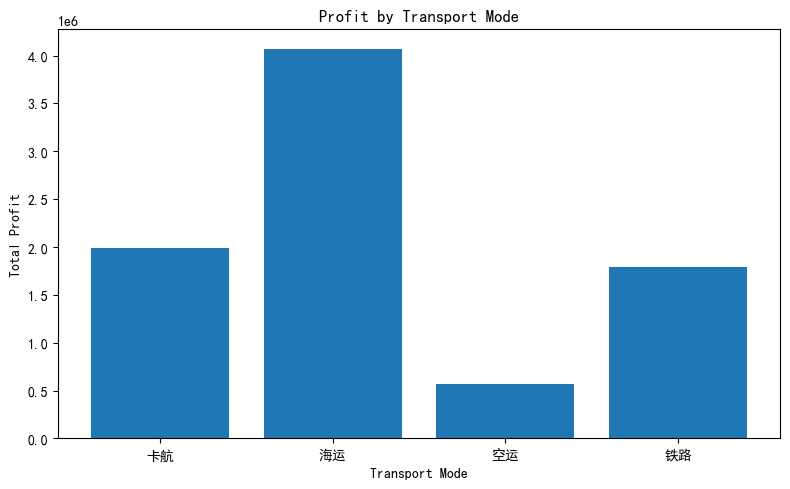

In [29]:
#利润vs运输方式
profit_by_mode = df.groupby(
    "transport_mode",
    as_index=False,
    observed=False
).agg(
    profit=("profit", "sum")
)

plt.figure(figsize=(8, 5))
plt.bar(profit_by_mode['transport_mode'], profit_by_mode['profit'])
plt.title('Profit by Transport Mode')
plt.xlabel('Transport Mode')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

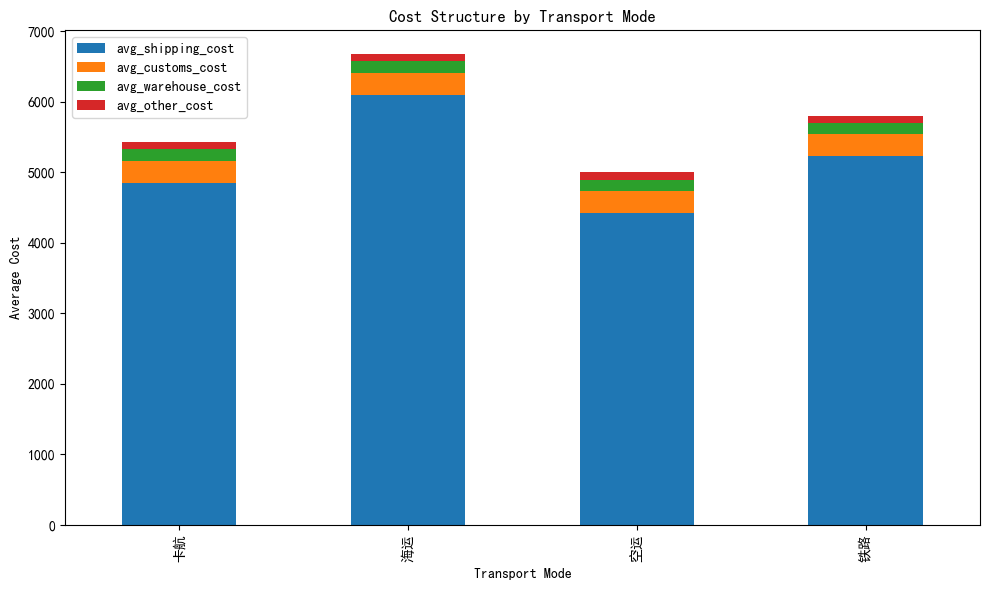

In [30]:
#成本结构图
cost_structure = df.groupby(
    "transport_mode",
    as_index=False,
    observed=False
).agg(
    avg_shipping_cost=("shipping_cost", "mean"),
    avg_customs_cost=("customs_cost", "mean"),
    avg_warehouse_cost=("warehouse_cost", "mean"),
    avg_other_cost=("other_cost", "mean")
)


cost_plot = cost_structure.set_index('transport_mode')[
    ['avg_shipping_cost', 'avg_customs_cost', 'avg_warehouse_cost', 'avg_other_cost']
]

cost_plot.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Cost Structure by Transport Mode')
plt.xlabel('Transport Mode')
plt.ylabel('Average Cost')
plt.tight_layout()
plt.show()

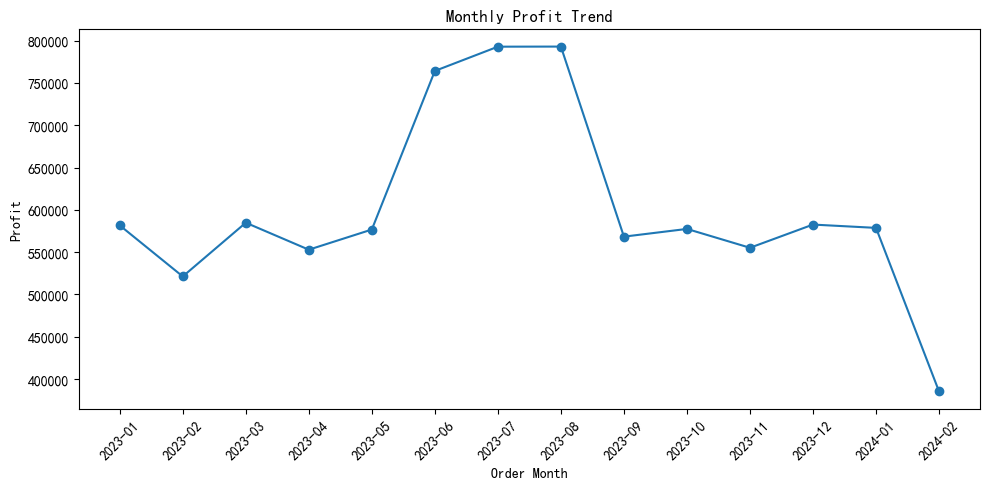

In [31]:
#月度利润趋势图
df["order_month"] = pd.to_datetime(df["order_date"]).dt.to_period("M")
monthly_trend = df.groupby(
    "order_month",
    as_index=False,
    observed=False
).agg(
    profit=("profit", "sum")
)

monthly_trend["order_month"] = monthly_trend["order_month"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend['order_month'], monthly_trend['profit'], marker='o')

plt.title('Monthly Profit Trend')
plt.xlabel('Order Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

结论：物流公司的主要成本是在干线运输费用，
1.海运运输成本占比最高，对运价波动敏感，优化方向在于运输成本控制（议价、线路优化）。
2.空运 附加成本占比更高，优化重点在于仓储、清关及操作流程效率。
3.卡航 / 铁路 成本结构相对均衡，但非运输成本占比高于海运，需要关注综合成本控制。

通过对公司订单、成本结构及履约表现的综合分析发现，公司整体利润和利润率在各月份保持稳定，未出现明显下降趋势。
履约方面，延误率长期维持在较高水平（约55%），但对当前利润影响有限，说明延误更多影响客户体验而非短期盈利。
整体来看，公司当前盈利能力稳定，但仍存在优化空间，主要集中在运输成本控制、运输方式结构优化以及履约稳定性提升等方面。